In [31]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [32]:
# === LOAD DATA ===
dataset = "dataset_rgb_96_binary_balanced.npz"  # ✅ New dataset
data = np.load(dataset, allow_pickle=True)
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
label_names = data["label_names"]
num_classes = len(label_names)
img_size = (96, 96)

print(f"Loaded dataset with {len(X_train)} training, {len(X_val)} validation, and {len(X_test)} test samples.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Classes: {label_names}")

Loaded dataset with 2501 training, 536 validation, and 536 test samples.
X_train shape: (2501, 96, 96, 3), y_train shape: (2501,)
X_val shape: (536, 96, 96, 3), y_val shape: (536,)
X_test shape: (536, 96, 96, 3), y_test shape: (536,)
Classes: ['NO_THREAT' 'THREAT']


In [33]:
# === Preprocess ===
X_train = preprocess_input(X_train)
X_val = preprocess_input(X_val)
X_test = preprocess_input(X_test)

print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}, X_test shape: {X_test.shape}")

X_train shape: (2501, 96, 96, 3), X_val shape: (536, 96, 96, 3), X_test shape: (536, 96, 96, 3)


In [ ]:
# === BUILD MODEL ===
base_model = MobileNetV2(
    input_shape=(96, 96, 3), 
    include_top=False,
    weights="imagenet",
    alpha=0.35  # keeps it small
)
base_model.trainable = False  # Freeze initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_0.35_96             │ (None, 3, 3, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 574,434 (2.19 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 410,208 (1.56 MB)

None


In [35]:
# === COMPILE ===
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
# === FINE-TUNE ===
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ModelCheckpoint("mobilenet96_best.h5", monitor="val_accuracy", save_best_only=True)
]

base_model.trainable = True
for layer in base_model.layers[:-30]:  # keep most frozen
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [37]:
# === TRAIN ===
history_ft = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,  # ✅ Larger batch fits because images are smaller
    callbacks=callbacks
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6696 - loss: 0.6571

79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.6706 - loss: 0.6556 - val_accuracy: 0.8433 - val_loss: 0.3525
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.8912 - loss: 0.2684 - val_accuracy: 0.8433 - val_loss: 0.3263
Epoch 3/10
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9200 - loss: 0.2148

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9201 - loss: 0.2145 - val_accuracy: 0.8619 - val_loss: 0.3102
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9572 - loss: 0.1297

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9572 - loss: 0.1297 - val_accuracy: 0.8881 - val_loss: 0.2737
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9611 - loss: 0.1049 - val_accuracy: 0.8787 - val_loss: 0.3150
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9812 - loss: 0.0747 - val_accuracy: 0.8750 - val_loss: 0.2924
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.9792 - loss: 0.0695 - val_accuracy: 0.8862 - val_loss: 0.2794
Epoch 8/10
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9859 - loss: 0.0577

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9859 - loss: 0.0575 - val_accuracy: 0.9142 - val_loss: 0.1956
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9933 - loss: 0.0356 - val_accuracy: 0.9104 - val_loss: 0.2046
Epoch 10/10
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9962 - loss: 0.0238

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9961 - loss: 0.0239 - val_accuracy: 0.9310 - val_loss: 0.1692


In [38]:
# === SAVE ===
model.save("mobilenetv2_96_best_model.h5")
print("Model saved as mobilenetv2_96_best_model.h5")


Model saved as mobilenetv2_96_best_model.h5


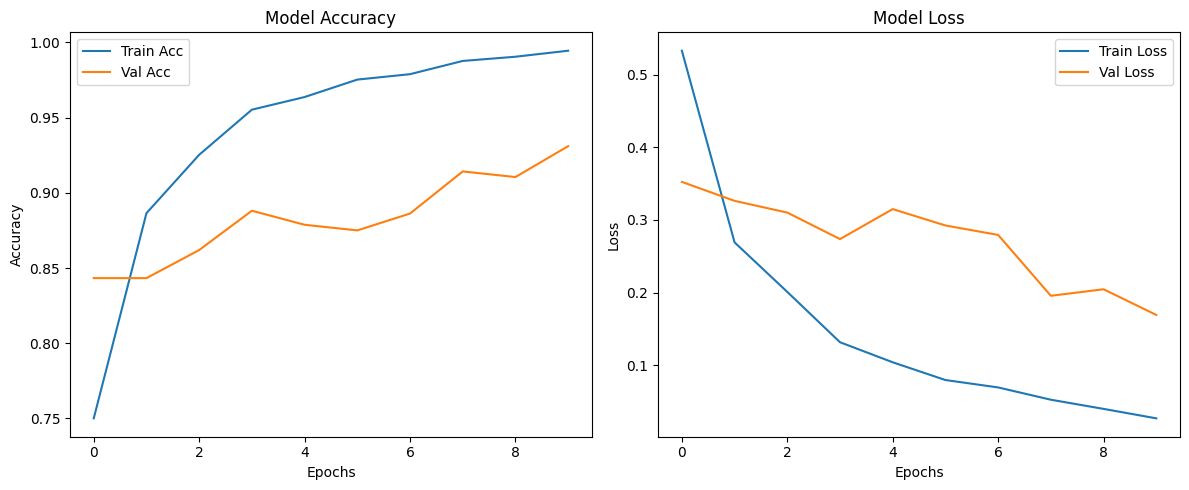

In [39]:
# === PLOT TRAINING CURVES ===
def plot_training(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Model Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call this after training
plot_training(history_ft)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step

Classification Report:
               precision    recall  f1-score   support

   NO_THREAT       0.98      0.81      0.89       222
      THREAT       0.88      0.99      0.93       314

    accuracy                           0.92       536
   macro avg       0.93      0.90      0.91       536
weighted avg       0.92      0.92      0.91       536

[[180  42]
 [  3 311]]


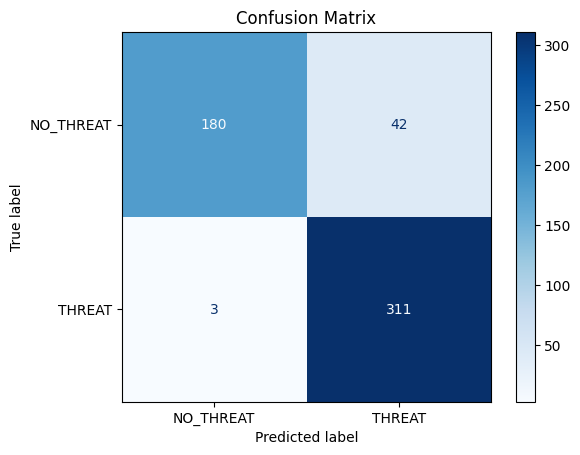

In [40]:
# === EVALUATE ON TEST ===
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_names))

cm = confusion_matrix(y_test, y_pred)
print(cm)

# Step 4: Display confusion matrix with sklearn's built-in tool
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

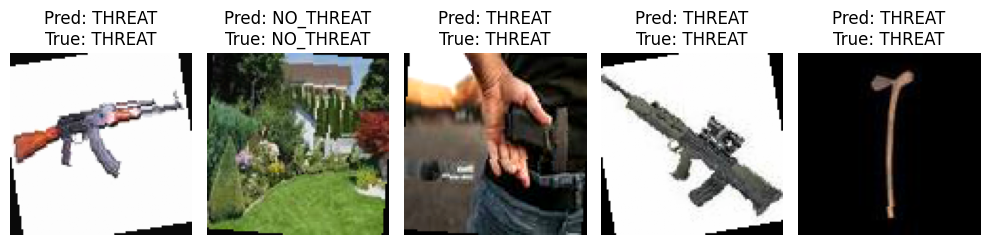

In [41]:
# === SHOW 5 RANDOM PREDICTIONS ===
plt.figure(figsize=(10, 4))
for i, idx in enumerate(random.sample(range(len(X_test)), 5)):
    plt.subplot(1, 5, i+1)
    plt.imshow((X_test[idx] + 1) / 2)  # inverse of preprocess_input
    plt.title(f"Pred: {label_names[y_pred[idx]]}\nTrue: {label_names[y_test[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()